# Financial Fraud Detection

## Exploratory Data Analysis (EDA) Using Python

### Name: Pragya Raghuwanshi

### Objective

The objective of this project is to analyze credit card transaction data and identify patterns related to fraudulent activities. Exploratory Data Analysis (EDA) is performed to understand transaction behavior, detect anomalies, identify influential factors, and generate insights that can support the development of an effective fraud detection system.

# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
df = pd.read_csv("cc_data.csv")

df.head()

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0


# Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389002 entries, 0 to 389001
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  389002 non-null  int64  
 1   trans_date_trans_time  389002 non-null  object 
 2   cc_num                 389002 non-null  int64  
 3   merchant               389002 non-null  object 
 4   category               389002 non-null  object 
 5   amt                    389002 non-null  float64
 6   first                  389002 non-null  object 
 7   last                   389002 non-null  object 
 8   gender                 389002 non-null  object 
 9   street                 389002 non-null  object 
 10  city                   389002 non-null  object 
 11  state                  389002 non-null  object 
 12  zip                    389002 non-null  int64  
 13  lat                    389002 non-null  float64
 14  long                   389002 non-nu

In [4]:
df.shape

(389002, 23)

# Task 6.1: What are the dimensions (number of rows and columns) of the dataset?

In [5]:
rows, cols = df.shape

print("Number of Rows :", rows)
print("Number of Columns :", cols)

Number of Rows : 389002
Number of Columns : 23


### Observation

The dataset contains transaction records along with customer, merchant, geographical, and fraud-related information. The dimensions indicate the overall size of the dataset used for fraud detection analysis.

# Task 6.2: Unique Values in Categorical Variables

In [6]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    print(f"\n{col}")
    print("Unique Values:", df[col].nunique())


trans_date_trans_time
Unique Values: 293627

merchant
Unique Values: 693

category
Unique Values: 14

first
Unique Values: 352

last
Unique Values: 481

gender
Unique Values: 2

street
Unique Values: 979

city
Unique Values: 890

state
Unique Values: 51

job
Unique Values: 492

dob
Unique Values: 964

trans_num
Unique Values: 389002


### Observation

The output shows the number of distinct values present in each categorical variable. Variables with a high number of unique values may require special handling during fraud detection model development.

# Task 6.3: Distribution of Numerical Variables

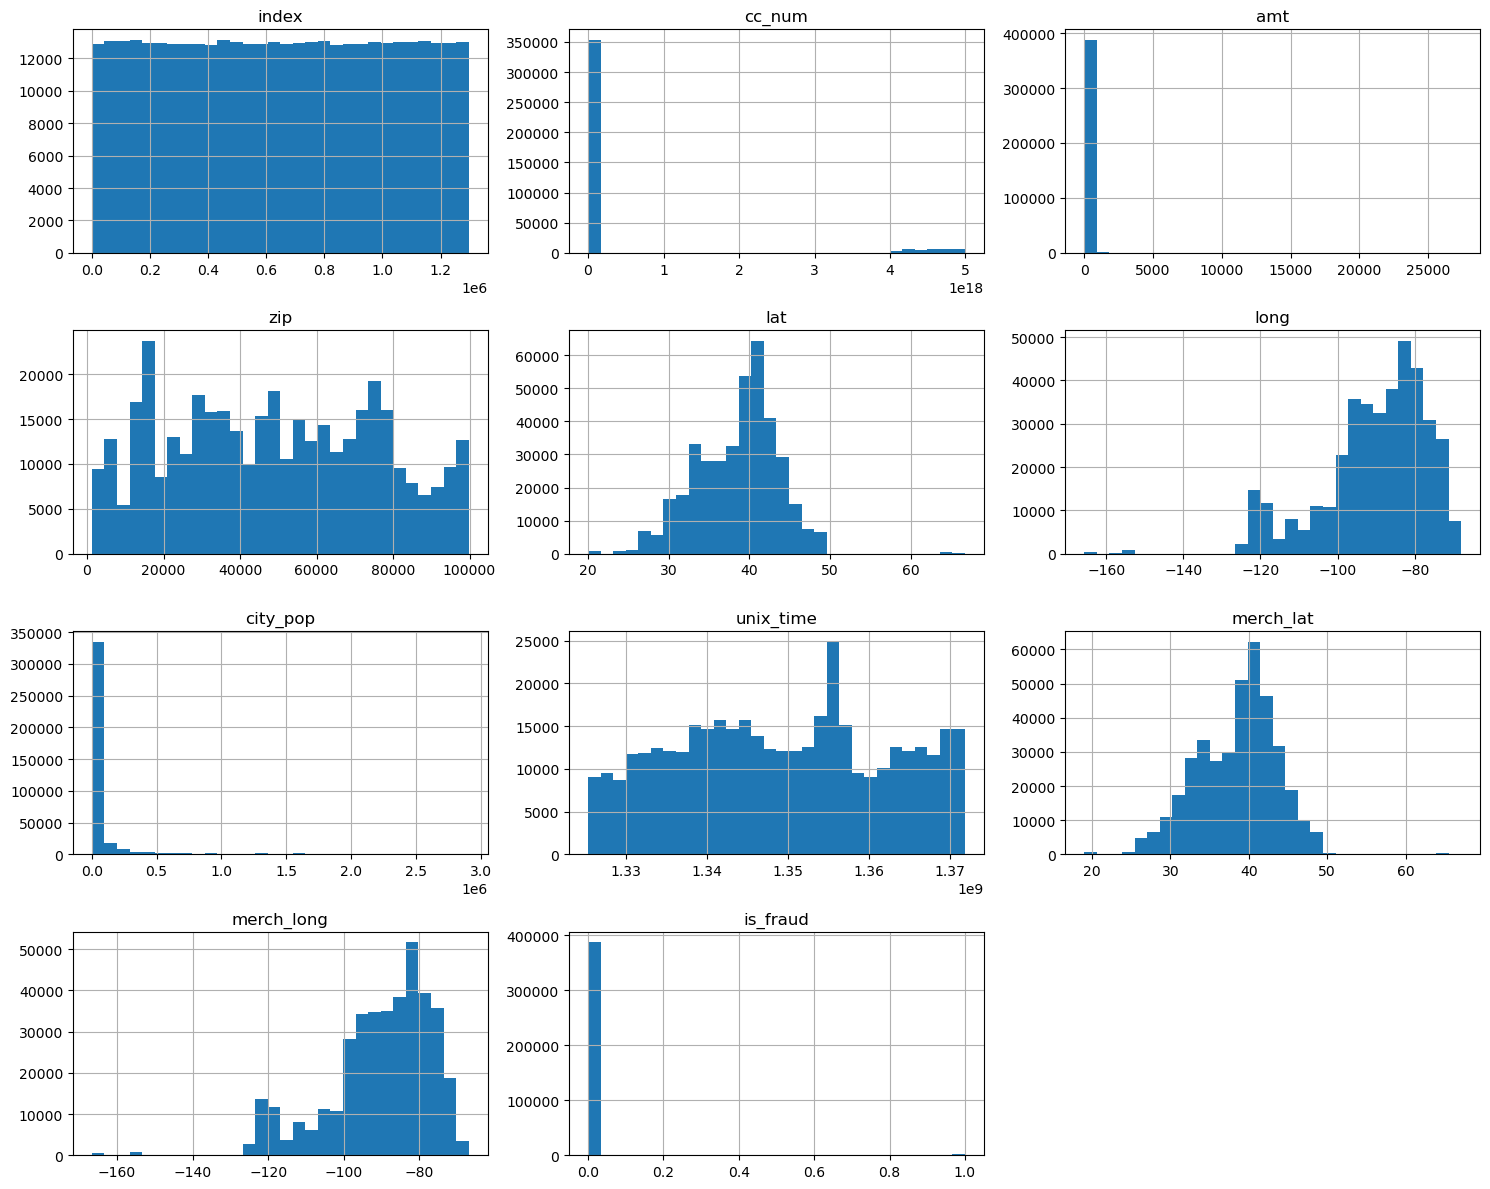

In [7]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

df[numerical_columns].hist(
    figsize=(15,12),
    bins=30
)

plt.tight_layout()
plt.show()

### Observation

The histograms provide insights into the distribution patterns of numerical variables. Variables such as transaction amount and city population may exhibit skewness and varying ranges.

# Task 6.4: Missing Value Analysis

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
df.isnull().sum().sort_values(
    ascending=False
)

index                    0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

### Observation

The analysis identifies columns containing missing values. Appropriate treatment such as imputation or removal may be applied depending on the extent and importance of missing data.

# Task 6.5: Summary Statistics for Numerical Variables

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,389002.0,6.485205e+05,3.745744e+05,1.100000e+01,3.241842e+05,6.486485e+05,9.735032e+05,1.296674e+06
cc_num,389002.0,4.191512e+17,1.311579e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,389002.0,7.044215e+01,1.622039e+02,1.000000e+00,9.660000e+00,4.757000e+01,8.307750e+01,2.739012e+04
zip,389002.0,4.881806e+04,2.687938e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.201100e+04,9.978300e+04
lat,389002.0,3.853312e+01,5.074596e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,389002.0,-9.023766e+01,1.374586e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,389002.0,8.868084e+04,3.012101e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,389002.0,1.349251e+09,1.285085e+07,1.325376e+09,1.338751e+09,1.349267e+09,1.359460e+09,1.371817e+09
merch_lat,389002.0,3.853168e+01,5.109400e+00,1.902980e+01,3.471939e+01,3.936107e+01,4.195601e+01,6.706428e+01
merch_long,389002.0,-9.023667e+01,1.375731e+01,-1.666696e+02,-9.690544e+01,-8.744684e+01,-8.025383e+01,-6.695654e+01


### Observation

Summary statistics provide information regarding the central tendency, dispersion, minimum values, maximum values, and variability of numerical variables in the dataset.

# Task 6.6: Correlation Between Numerical Variables

In [11]:
correlation_matrix = df.corr(
    numeric_only=True
)

correlation_matrix

,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
index,1.000000,0.001289,0.000779,0.000874,-0.000193,-0.001494,-0.001800,0.998976,-0.000383,-0.001475,-0.006121
cc_num,0.001289,1.000000,0.002975,0.040486,-0.059182,-0.047587,-0.009125,0.001333,-0.058560,-0.047549,-0.001280
amt,0.000779,0.002975,1.000000,0.001756,-0.000445,-0.000517,0.007271,0.000780,-0.000314,-0.000578,0.210706
zip,0.000874,0.040486,0.001756,1.000000,-0.112567,-0.910295,0.078373,0.000905,-0.111689,-0.909470,-0.001220
lat,-0.000193,-0.059182,-0.000445,-0.112567,1.000000,-0.016080,-0.155972,-0.000150,0.993599,-0.015994,0.002643
long,-0.001494,-0.047587,-0.000517,-0.910295,-0.016080,1.000000,-0.053461,-0.001608,-0.016010,0.999119,0.001376
city_pop,-0.001800,-0.009125,0.007271,0.078373,-0.155972,-0.053461,1.000000,-0.001766,-0.154767,-0.053468,0.001176
unix_time,0.998976,0.001333,0.000780,0.000905,-0.000150,-0.001608,-0.001766,1.000000,-0.000354,-0.001582,-0.006562
merch_lat,-0.000383,-0.058560,-0.000314,-0.111689,0.993599,-0.016010,-0.154767,-0.000354,1.000000,-0.015932,0.002406
merch_long,-0.001475,-0.047549,-0.000578,-0.909470,-0.015994,0.999119,-0.053468,-0.001582,-0.015932,1.000000,0.001351


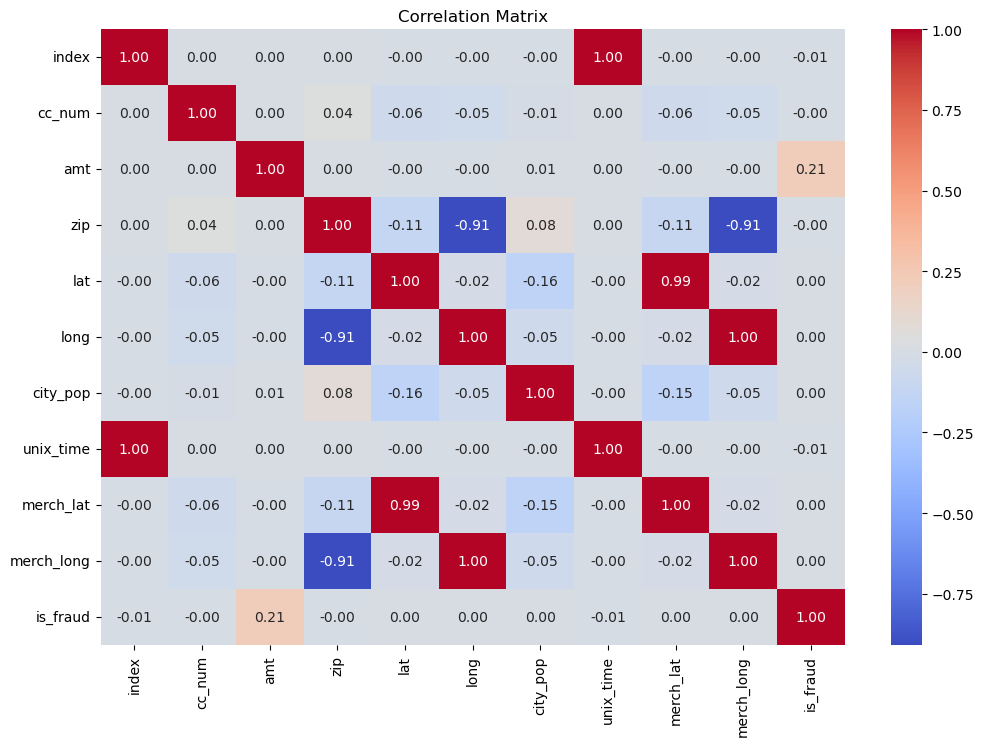

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Observation

The correlation matrix helps identify relationships among numerical variables. Strong positive or negative correlations may indicate influential factors relevant to fraud detection.

# Task 6.7: Distribution of Transaction Amount Across Fraud Categories

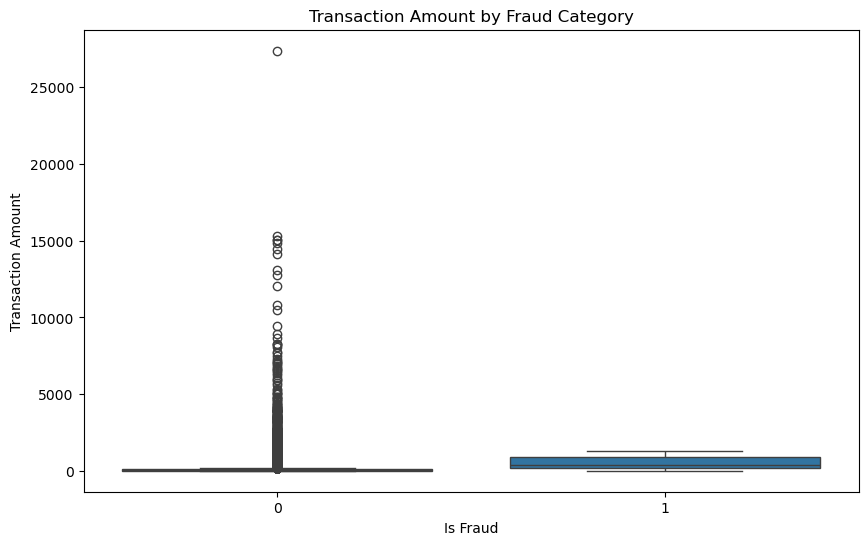

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='is_fraud',
    y='amt',
    data=df
)

plt.title('Transaction Amount by Fraud Category')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

plt.show()

### Observation

The boxplot compares transaction amounts between fraudulent and non-fraudulent transactions. Differences in spread and median values may indicate distinct spending patterns associated with fraudulent activities.

# Task 6.8: Outlier Detection

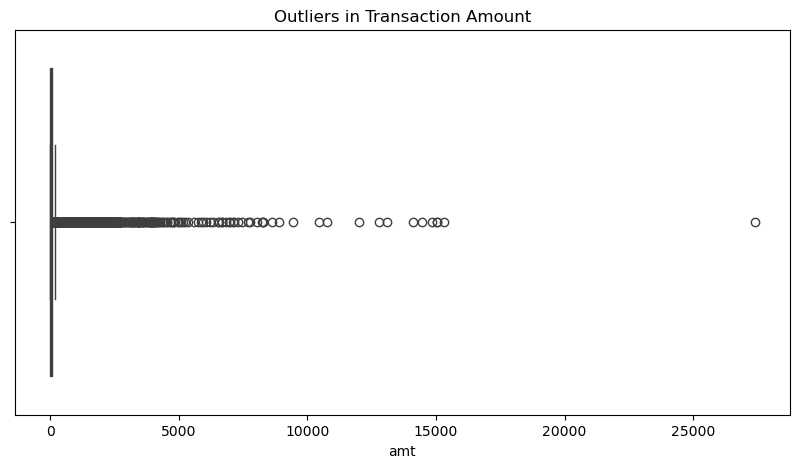

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['amt'])

plt.title('Outliers in Transaction Amount')
plt.show()

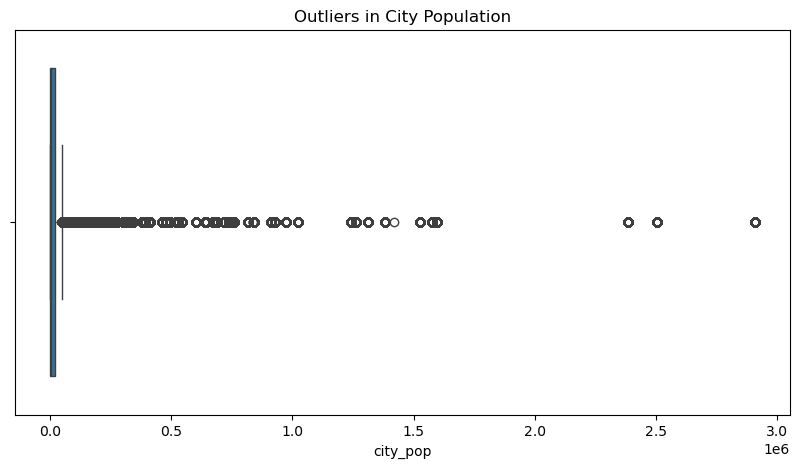

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['city_pop'])

plt.title('Outliers in City Population')
plt.show()

### Observation

Boxplots help identify extreme observations in transaction amount and city population. These outliers may represent unusual customer behavior or potentially suspicious transactions.

# Task 6.9: Time Trend Analysis

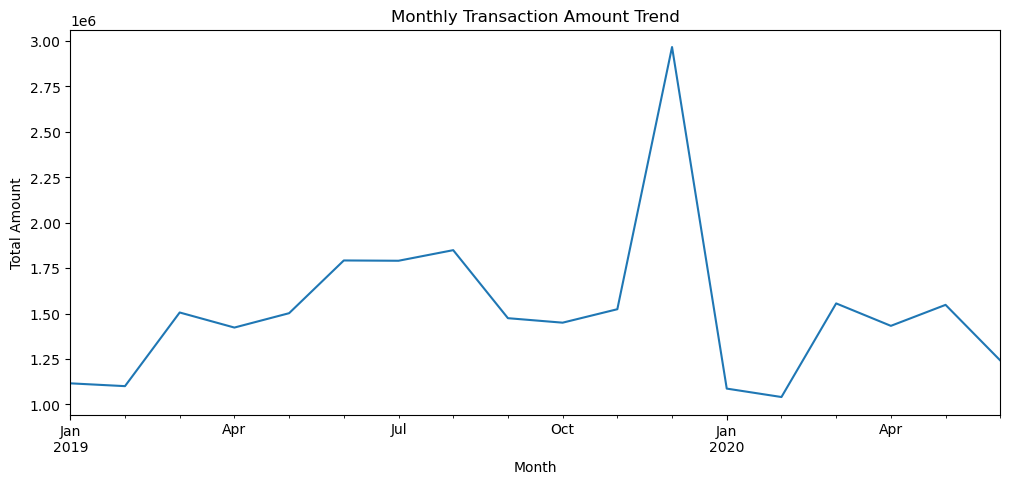

In [31]:
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time'],
    dayfirst=True,
    errors='coerce'
)

monthly_trend = df.groupby(
    df['trans_date_trans_time'].dt.to_period('M')
)['amt'].sum()

monthly_trend.plot(
    figsize=(12,5)
)

plt.title('Monthly Transaction Amount Trend')
plt.xlabel('Month')
plt.ylabel('Total Amount')

plt.show()
monthly_trend = df.groupby(
    df['trans_date_trans_time'].dt.to_period('M')
)['amt'].sum()

monthly_trend = monthly_trend.sort_index()

### Observation

The time series chart shows transaction trends over time and helps identify seasonal patterns, spikes, or unusual transaction behavior.

# Task 6.10: Fraud Distribution Across Categories

In [19]:
fraud_category = pd.crosstab(
    df['category'],
    df['is_fraud']
)

fraud_category

is_fraud,0,1
category,,
entertainment,28054,68
food_dining,27028,42
gas_transport,39440,193
grocery_net,13806,40
grocery_pos,36245,518
health_fitness,25693,39
home,36832,65
kids_pets,33833,74
misc_net,18825,287


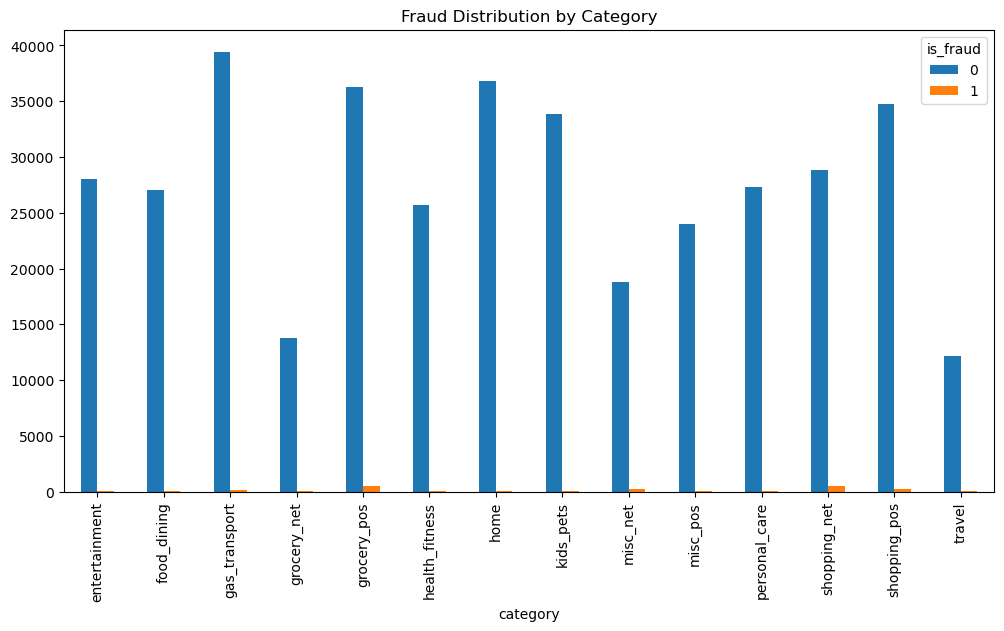

In [20]:
fraud_category.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Fraud Distribution by Category')

plt.show()

### Observation

This analysis identifies categories that experience higher levels of fraudulent transactions and highlights fraud-prone transaction types.

# Task 6.11: Unusual or Unexpected Values

In [21]:
df[['amt','city_pop']].describe()

,amt,city_pop
count,389002.000000,3.890020e+05
mean,70.442148,8.868084e+04
std,162.203915,3.012101e+05
min,1.000000,2.300000e+01
25%,9.660000,7.430000e+02
50%,47.570000,2.456000e+03
75%,83.077500,2.032800e+04
max,27390.120000,2.906700e+06


In [22]:
df[df['amt'] < 0]

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


In [23]:
df[df['city_pop'] < 0]

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


### Observation

The analysis checks for unusual values such as negative transaction amounts or invalid city population values. Such records may require further investigation before model development.

# Task 6.12: Data Quality and Consistency Check

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df[['gender','state','category']].nunique()

gender       2
state       51
category    14
dtype: int64

### Observation

Duplicate records and inconsistencies in categorical variables may impact fraud detection performance. Data quality checks help ensure reliable analysis results.

# Task 6.13: Group-wise Numerical Analysis

In [26]:
df.groupby('gender')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,213231.0,69.854789,151.442906,1.0,9.10,43.37,83.67,15034.18
M,175771.0,71.154684,174.366858,1.0,11.59,51.82,82.56,27390.12


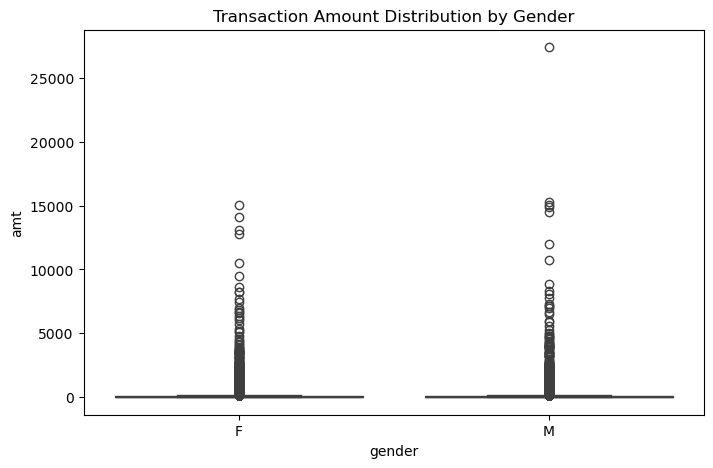

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='gender',
    y='amt',
    data=df
)

plt.title('Transaction Amount Distribution by Gender')

plt.show()

### Observation

The analysis compares transaction amount distributions across genders and highlights differences in spending behavior among customer groups.

# Task 6.14: Factors Influencing Fraud

In [28]:
correlation_with_target = correlation_matrix['is_fraud'].sort_values(
    ascending=False
)

correlation_with_target

is_fraud      1.000000
amt           0.210706
lat           0.002643
merch_lat     0.002406
long          0.001376
merch_long    0.001351
city_pop      0.001176
zip          -0.001220
cc_num       -0.001280
index        -0.006121
unix_time    -0.006562
Name: is_fraud, dtype: float64

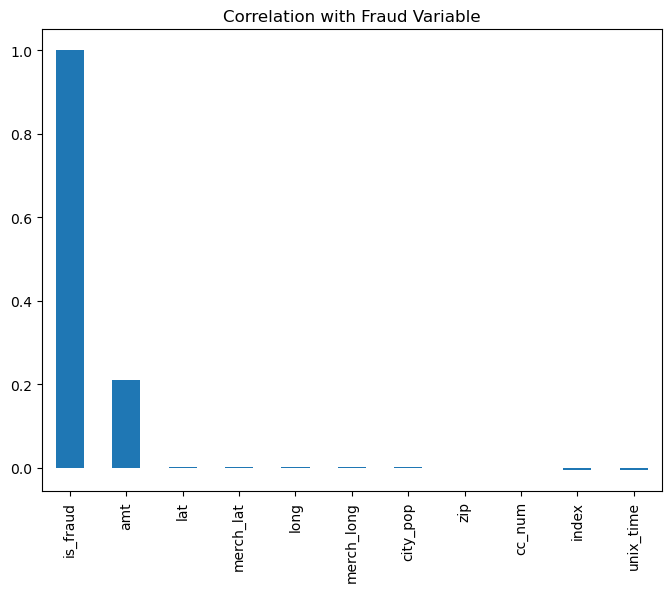

In [29]:
plt.figure(figsize=(8,6))

correlation_with_target.plot(
    kind='bar'
)

plt.title('Correlation with Fraud Variable')

plt.show()

In [32]:
fraud_rate_by_category = pd.crosstab(
    df['category'],
    df['is_fraud'],
    normalize='index'
) * 100

fraud_rate_by_category

is_fraud,0,1
category,,
entertainment,99.758196,0.241804
food_dining,99.844847,0.155153
gas_transport,99.513032,0.486968
grocery_net,99.711108,0.288892
grocery_pos,98.590975,1.409025
health_fitness,99.848438,0.151562
home,99.823834,0.176166
kids_pets,99.781756,0.218244
misc_net,98.498326,1.501674


### Observation

Variables with stronger correlations to the fraud indicator may have greater influence on fraudulent transaction behavior and can be considered important predictors.

# Final EDA Report

## Financial Fraud Detection

### Summary

Exploratory Data Analysis was conducted on the financial transaction dataset to understand customer behavior, transaction characteristics, fraud patterns, and data quality.

### Key Findings

- The dataset contains transaction, customer, merchant, and location information.
- Numerical variables such as transaction amount and city population show considerable variation.
- Correlation analysis revealed generally weak linear relationships among variables.
- Fraudulent transactions exhibit different transaction amount distributions compared to non-fraudulent transactions.
- Outliers were identified in both transaction amount and city population.
- Transaction activity varies across categories, genders, and time periods.
- Certain categories show higher concentrations of fraudulent activity.
- Data quality checks identified duplicate records and validated dataset consistency.

### Conclusion

The EDA process provided valuable insights into transaction behavior and fraud patterns. These findings establish a strong foundation for developing effective fraud detection models and identifying suspicious financial activities.